<a href="https://colab.research.google.com/github/Meenakshimadhu192001/Case_study/blob/main/Case_study7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Libraries

In [17]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar100
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical, plot_model

# For Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Model Building
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D,
                                     BatchNormalization, Dropout,
                                     Flatten, Dense)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.initializers import HeNormal

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

##Loading Dataset

In [18]:
# Load dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

In [19]:
# Print dataset shapes
print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)


Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Test images: (10000, 32, 32, 3)
Test labels: (10000, 1)


##Data Augumentation

In [20]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name="data_augmentation")

##Model Building

####CNN

In [21]:
# Build Custom CNN
# Conv2D(32, 3x3) learns 32 low-level feature maps (edges, colors) → BatchNormalization stabilizes/speeds up training → MaxPooling2D(2x2) halves the spatial size (32×32 → 16×16)
model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

#Conv2D(64, 3x3) learns more complex features → BatchNorm → pooling (16×16 → 8×8)
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

#Conv2D(128, 3x3) learns even higher-level features → BatchNorm → pooling (8×8 → 4×4)

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

#Flatten: turns the final 4×4×128 feature map into a 1D vector (2048 values) so it can feed into dense layers
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(100, activation='softmax')
])

# Display model summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 644,388 (2.46 MB)

 Trainable params: 643,940 (2.46 MB)

 Non-trainable params: 448 (1.75 KB)

In [22]:
#combiling model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
# Train the model
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 130s 204ms/step - accuracy: 0.0508 - loss: 4.3331 - val_accuracy: 0.0932 - val_loss: 3.9591
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 125s 200ms/step - accuracy: 0.0967 - loss: 3.9060 - val_accuracy: 0.1700 - val_loss: 3.5130
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 141s 198ms/step - accuracy: 0.1320 - loss: 3.6508 - val_accuracy: 0.1913 - val_loss: 3.3254
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 133s 212ms/step - accuracy: 0.1654 - loss: 3.4420 - val_accuracy: 0.2295 - val_loss: 3.1987
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 140s 209ms/step - accuracy: 0.1991 - loss: 3.2495 - val_accuracy: 0.2592 - val_loss: 3.0060


In [24]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(x_test, y_test)

# Print results
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.2563 - loss: 2.9750
Test Loss: 2.9750003814697266
Test Accuracy: 0.2563000023365021


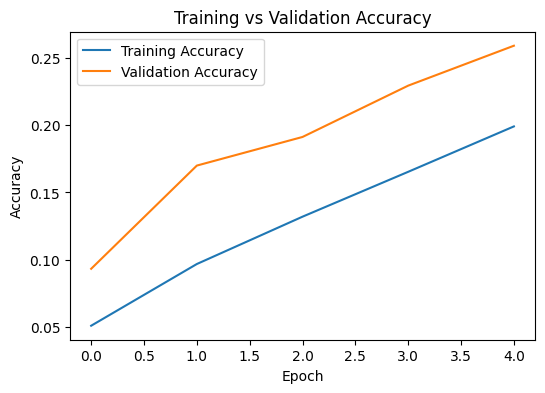

In [25]:
#Plot the training and validation accuracy/loss curves
# Plot Accuracy
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

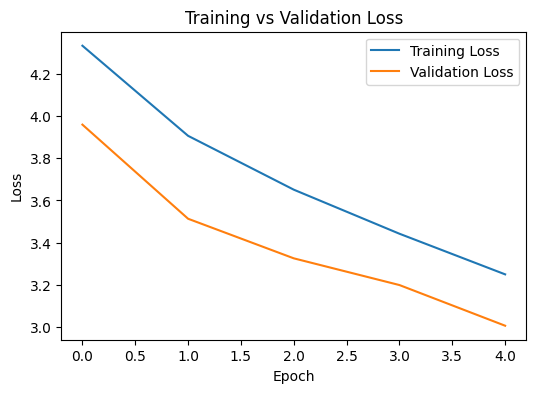

In [26]:
# Plot Loss
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

####VGG

In [27]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(32, 32, 3)
)

# Freeze the pretrained layers
base_model.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [28]:
##Build the VGG-16 mode
vgg_model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(100, activation='softmax')
])

vgg_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,871,716 (56.73 MB)

 Trainable params: 157,028 (613.39 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [29]:
vgg_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
print(y_train.shape)
print(y_test.shape)

(50000, 1)
(10000, 1)


In [31]:
from tensorflow.keras.utils import to_categorical #model outputs 100 probabilities (output.shape = (64, 100)), but labels are still integers (target.shape = (64, 1)).

y_train = to_categorical(y_train, 100)
y_test = to_categorical(y_test, 100)

In [32]:
#train the model
history_vgg = vgg_model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 572s 912ms/step - accuracy: 0.0452 - loss: 6.3766 - val_accuracy: 0.0964 - val_loss: 4.2501
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 534s 854ms/step - accuracy: 0.0927 - loss: 4.2226 - val_accuracy: 0.1510 - val_loss: 3.8365
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 529s 847ms/step - accuracy: 0.1245 - loss: 3.9239 - val_accuracy: 0.1830 - val_loss: 3.5909
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 565s 904ms/step - accuracy: 0.1453 - loss: 3.7492 - val_accuracy: 0.1991 - val_loss: 3.4656
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 570s 912ms/step - accuracy: 0.1598 - loss: 3.6166 - val_accuracy: 0.2099 - val_loss: 3.3493
